# 04 Sentiment Model Training

Goal: fine-tune `distilroberta-base` on `takala/financial_phrasebank` for 3-class sentiment classification (`positive`, `negative`, `neutral`).

This notebook covers:
- loading the dataset from Hugging Face
- train / validation split
- tokenization with `AutoTokenizer`
- model fine-tuning with the `Trainer` API
- evaluation using accuracy, precision, recall, and F1
- confusion matrix visualization
- saving the trained model
- example predictions


In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns
import torch

from datasets import DatasetDict, load_dataset
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

SEED = 42
BASE_MODEL = "distilroberta-base"
DATASET_NAME = "takala/financial_phrasebank"
OUTPUT_DIR = Path("./sentiment_distilroberta_financial_phrasebank")
MAX_TOKEN_LENGTH = 256

def set_seed(seed: int = 42) -> None:
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")
print(f"Torch version: {torch.__version__}")

Using device: cuda
Torch version: 2.10.0+cu130


## 4.1 Load Dataset

The dataset stores sentiment labels either as strings or `ClassLabel` integers depending on configuration, so we standardize them before training.

In [2]:
# Load one of the standard Financial PhraseBank configurations.
# Other common options are: sentences_75agree, sentences_66agree, sentences_50agree.
raw_dataset = load_dataset(
    DATASET_NAME,
    "sentences_allagree",
    trust_remote_code=True
)
raw_dataset

data/FinancialPhraseBank-v1.0.zip:   0%|          | 0.00/682k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2264 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2264
    })
})

In [4]:
base_dataset = raw_dataset['train']
base_dataset.to_pandas().head()

,sentence,label
0,"According to Gran , the company has no plans t...",1
1,"For the last quarter of 2010 , Componenta 's n...",2
2,"In the third quarter of 2010 , net sales incre...",2
3,Operating profit rose to EUR 13.1 mn from EUR ...,2
4,"Operating profit totalled EUR 21.1 mn , up fro...",2


In [6]:
label_list = ["negative", "neutral", "positive"]
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}

dataset_label_feature = base_dataset.features['label']

def add_label_id(example):
    raw_label = example['label']
    if isinstance(raw_label, str):
        label_text = raw_label
    else:
        label_text = dataset_label_feature.int2str(raw_label)
    example["label_text"] = label_text
    example["label_id"] = label2id[label_text]
    return example

base_dataset = base_dataset.map(add_label_id)
label_counts = pd.Series(base_dataset["label_text"]).value_counts().reindex(label_list, fill_value=0)
print("Label distribution:")
display(label_counts.to_frame(name="count"))

Map:   0%|          | 0/2264 [00:00<?, ? examples/s]

Label distribution:


,count
negative,303
neutral,1391
positive,570


In [7]:
# Train-test split with stratification to maintain label distribution

indices = np.arange(len(base_dataset))
train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=base_dataset["label_id"],
)

dataset = DatasetDict({
    "train": base_dataset.select(train_indices),
    "validation": base_dataset.select(val_indices),
})

print(dataset)
print("Train size:", len(dataset["train"]))
print("Validation size:", len(dataset["validation"]))

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'label_text', 'label_id'],
        num_rows: 1811
    })
    validation: Dataset({
        features: ['sentence', 'label', 'label_text', 'label_id'],
        num_rows: 453
    })
})
Train size: 1811
Validation size: 453


## 4.2 Train

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize_batch(batch):
    """Tokenize a batch of sentences with truncation for sequence classification."""
    return tokenizer(
        batch['sentence'],
        truncation=True,
        max_length=MAX_TOKEN_LENGTH,
    )

tokenized_dataset = dataset.map(tokenize_batch, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label_id", "labels")
tokenized_dataset = tokenized_dataset.remove_columns(["label", "label_text"])
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized_dataset


Map:   0%|          | 0/453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 1811
    })
    validation: Dataset({
        features: ['sentence', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 453
    })
})

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

def compute_metrics(eval_pred):
    """Compute classification metrics from model logits."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0,
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    seed=SEED,
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_608916/818554219.py:46: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.558200,0.151726,0.951435,0.953883,0.951435,0.950580
2,0.127100,0.079561,0.980132,0.980798,0.980132,0.980237
3,0.057200,0.118026,0.975717,0.976897,0.975717,0.975922
4,0.035300,0.100376,0.977925,0.978831,0.977925,0.978077


TrainOutput(global_step=456, training_loss=0.19443232553047046, metrics={'train_runtime': 35.5005, 'train_samples_per_second': 204.054, 'train_steps_per_second': 12.845, 'total_flos': 109793628728712.0, 'train_loss': 0.19443232553047046, 'epoch': 4.0})

## 4.3 Evaluation

In [12]:
eval_metrics = trainer.evaluate()
eval_metrics

{'eval_loss': 0.07956057041883469,
 'eval_accuracy': 0.9801324503311258,
 'eval_precision': 0.9807980202092038,
 'eval_recall': 0.9801324503311258,
 'eval_f1': 0.980237288385863,
 'eval_runtime': 0.5152,
 'eval_samples_per_second': 879.236,
 'eval_steps_per_second': 56.287,
 'epoch': 4.0}

In [13]:
pred_output = trainer.predict(tokenized_dataset["validation"])
val_logits = pred_output.predictions
val_labels = pred_output.label_ids
val_preds = np.argmax(val_logits, axis=-1)

report = classification_report(
    val_labels,
    val_preds,
    target_names=label_list,
    zero_division=0,
)
print(report)

              precision    recall  f1-score   support

    negative       0.98      0.95      0.97        61
     neutral       1.00      0.98      0.99       278
    positive       0.94      0.99      0.97       114

    accuracy                           0.98       453
   macro avg       0.97      0.97      0.97       453
weighted avg       0.98      0.98      0.98       453



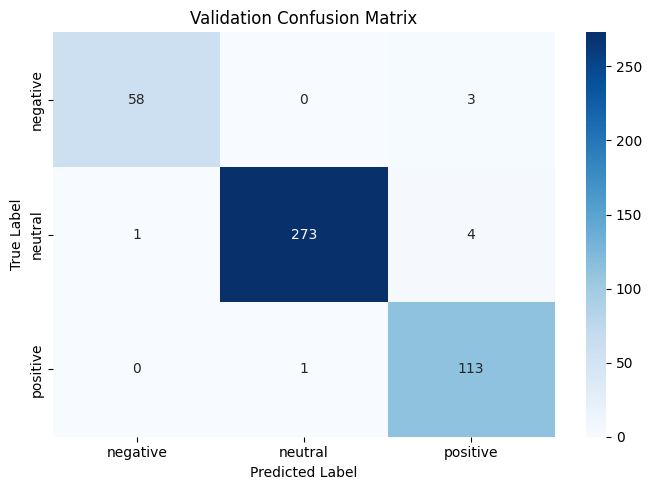

In [17]:
# Confusion Matrix

cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_list,
    yticklabels=label_list,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [18]:
# Save model

trainer.save_model(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

print(f"Saved model to: {OUTPUT_DIR.resolve()}")

Saved model to: /home/threeg/code/local/zjy-nlp-2603/sentiment_distilroberta_financial_phrasebank


## 4.4 Apply Model to Article Summaries

In [19]:
summary_df = pd.read_parquet('024_labeled_cluster_data.parquet')
summary_df.head()

,date,title,summary,organization,industry,impact,technology,cluster,topic
0,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",Bad Idea AI (BAD) is a cryptocurrency with a c...,Bad Idea AI,Cryptocurrency,0,AI,-1,
1,2024-07-01,This AI video of gymnastics might be the freak...,AI-generated videos of gymnastics and wrestlin...,Luma Dream Machine,Media and Entertainment,-2,AI-generated video,-1,
2,2024-09-22,"If using AI feels like a chore, try this - Boi...",1minAI offers a lifetime subscription for $39....,1minAI,Software,1,"GPT-4, Gemini Pro, Claude",1292,AI tools and services with lifetime or discoun...
3,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,"China's AI Foundation Model, developed by Baid...",Baidu,Automotive,2,"deep learning, big data, cloud computing",-1,
4,2023-11-19,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia are collaborating to empo...,Microsoft and Nvidia,Technology,1,Windows AI Studio and TensorRT-LLM,-1,


In [22]:
clf = pipeline(
    "text-classification",
    model="sentiment_distilroberta_financial_phrasebank",
    tokenizer="sentiment_distilroberta_financial_phrasebank",
)

preds = clf(
    summary_df["summary"].tolist(),
    batch_size=32,
    truncation=True,
    max_length=MAX_TOKEN_LENGTH
)

summary_df["sentiment"] = [x["label"] for x in preds]
summary_df["score"] = [x["score"] for x in preds]
summary_df.head()

Device set to use cuda:0


,date,title,summary,organization,industry,impact,technology,cluster,topic,sentiment,score
0,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",Bad Idea AI (BAD) is a cryptocurrency with a c...,Bad Idea AI,Cryptocurrency,0,AI,-1,,positive,0.991026
1,2024-07-01,This AI video of gymnastics might be the freak...,AI-generated videos of gymnastics and wrestlin...,Luma Dream Machine,Media and Entertainment,-2,AI-generated video,-1,,neutral,0.857456
2,2024-09-22,"If using AI feels like a chore, try this - Boi...",1minAI offers a lifetime subscription for $39....,1minAI,Software,1,"GPT-4, Gemini Pro, Claude",1292,AI tools and services with lifetime or discoun...,neutral,0.990789
3,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,"China's AI Foundation Model, developed by Baid...",Baidu,Automotive,2,"deep learning, big data, cloud computing",-1,,neutral,0.511328
4,2023-11-19,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia are collaborating to empo...,Microsoft and Nvidia,Technology,1,Windows AI Studio and TensorRT-LLM,-1,,positive,0.982978


In [31]:
summary_df.to_parquet('040_sentiment.parquet')